In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf


print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print("Available devices:", tf.config.list_physical_devices())


Num GPUs Available: 1
Available devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os
import cv2
import numpy as np

# Define paths
train_image_dir = '/content/drive/MyDrive/train'
train_mask_dir  = '/content/drive/MyDrive/train_labels'

val_image_dir   = '/content/drive/MyDrive/val'
val_mask_dir    = '/content/drive/MyDrive/val_labels'

test_image_dir  = '/content/drive/MyDrive/test'
test_mask_dir   = '/content/drive/MyDrive/test_labels'



def load_images(image_dir, mask_dir, img_size=(256,256), use_fraction=1.0):
    image_list, mask_list = [], []

    files = [f for f in os.listdir(image_dir) if f.endswith('.tiff')]
    files.sort()


    n_files = int(len(files) * use_fraction)
    files = files[:n_files]

    print(f"Loading {n_files} images from {image_dir}")

    for image_name in files:
        img_path  = os.path.join(image_dir, image_name)
        mask_name = os.path.splitext(image_name)[0] + '.tif'
        mask_path = os.path.join(mask_dir, mask_name)

        if os.path.exists(mask_path):
            img  = cv2.imread(img_path)
            img  = cv2.resize(img, img_size)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, img_size)

            image_list.append(img)
            mask_list.append(mask)


    images = np.array(image_list, dtype=np.float32) / 255.0
    masks  = np.array(mask_list, dtype=np.float32) / 255.0
    masks  = (masks > 0.5).astype(np.float32)
    masks  = np.expand_dims(masks, axis=-1)

    return images, masks



X_train, y_train = load_images(train_image_dir, train_mask_dir, img_size=(256,256), use_fraction=0.2)
X_val, y_val     = load_images(val_image_dir, val_mask_dir, img_size=(256,256), use_fraction=1.0)
X_test, y_test   = load_images(test_image_dir, test_mask_dir, img_size=(256,256), use_fraction=1.0)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


Loading 221 images from /content/drive/MyDrive/train
Loading 14 images from /content/drive/MyDrive/val
Loading 49 images from /content/drive/MyDrive/test
Train: (221, 256, 256, 3) (221, 256, 256, 1)
Val: (14, 256, 256, 3) (14, 256, 256, 1)
Test: (49, 256, 256, 3) (49, 256, 256, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def unet_model(input_shape=(256, 256, 3)): # Changed input shape to match data
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # Bottleneck
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c3)

    # Decoder
    u4 = layers.UpSampling2D((2, 2))(c3)
    u4 = layers.Concatenate()([u4, c2])
    c4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u4)
    c4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c4)

    u5 = layers.UpSampling2D((2, 2))(c4)
    u5 = layers.Concatenate()([u5, c1])
    c5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c5)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c5)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


model = unet_model(input_shape=(256, 256, 3)) # Pass the correct input shape

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=8
)


Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9546 - loss: 0.3384 - val_accuracy: 0.9309 - val_loss: 0.2875
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 270ms/step - accuracy: 0.9579 - loss: 0.1848 - val_accuracy: 0.9309 - val_loss: 0.2491
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 275ms/step - accuracy: 0.9598 - loss: 0.1648 - val_accuracy: 0.9309 - val_loss: 0.2356
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 279ms/step - accuracy: 0.9598 - loss: 0.1448 - val_accuracy: 0.9309 - val_loss: 0.2152
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 278ms/step - accuracy: 0.9581 - loss: 0.1416 - val_accuracy: 0.9309 - val_loss: 0.2191
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 274ms/step - accuracy: 0.9583 - loss: 0.1374 - val_accuracy: 0.9309 - val_loss: 0.2312
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 272ms/step - accuracy: 0.9587 - loss: 0.1340 - val_accuracy: 0.9309 - val_loss: 0.2063
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 278ms/step - accuracy: 0.9605 - loss: 0.1263 - val_accuracy:

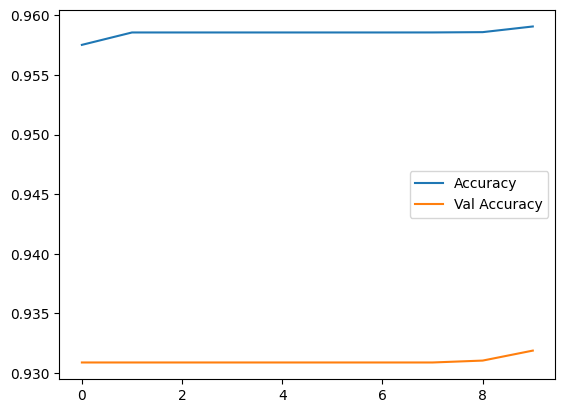

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step


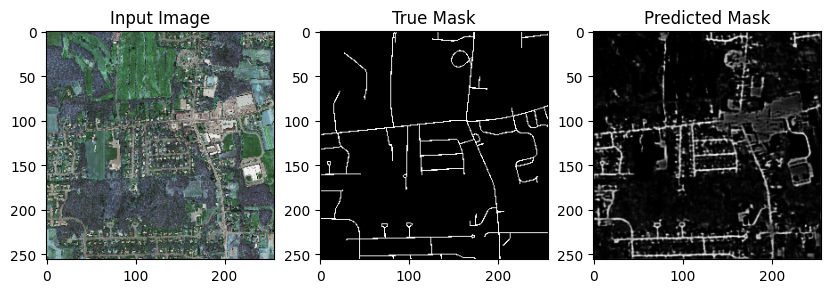

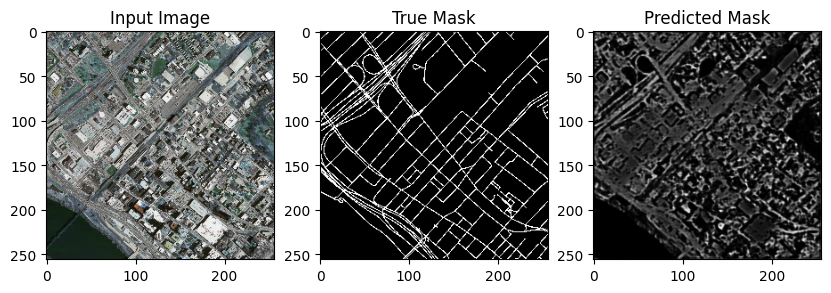

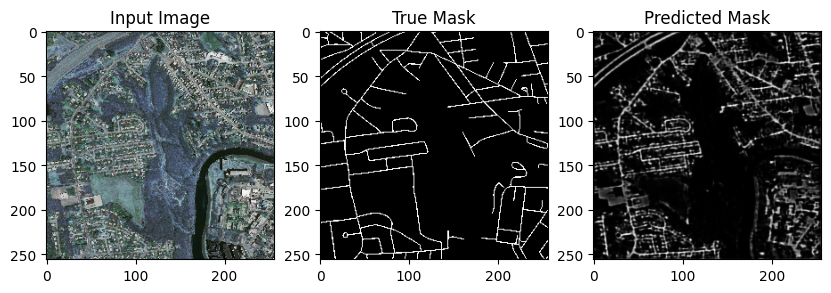

In [ ]:
import matplotlib.pyplot as plt

# Plot training history
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.show()

# Run predictions on validation images
predictions = model.predict(X_val)

# Visualize predictions
def display_predictions(images, masks, predictions, num=3):
    for i in range(num):
        plt.figure(figsize=(10, 5))

        plt.subplot(1, 3, 1)
        plt.title('Input Image')
        plt.imshow(images[i])

        plt.subplot(1, 3, 2)
        plt.title('True Mask')
        plt.imshow(masks[i].squeeze(), cmap='gray')

        plt.subplot(1, 3, 3)
        plt.title('Predicted Mask')
        plt.imshow(predictions[i].squeeze(), cmap='gray')

        plt.show()

display_predictions(X_val, y_val, predictions)

In [24]:
model.save('/content/drive/MyDrive/unet_model.h5')
